# Инициализация

Загружаем библиотеки необходимые для выполнения кода ноутбука.

In [ ]:
import pandas as pd
import numpy as np
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style="whitegrid")

# === ЭТАП 1 ===

# Загрузка первичных данных

Загружаем первичные данные из файлов:
- tracks.parquet
- catalog_names.parquet
- interactions.parquet

In [ ]:
tracks_df = pd.read_parquet('tracks.parquet')
catalog_names_df = pd.read_parquet('catalog_names.parquet')
interactions_df = pd.read_parquet('interactions.parquet')

Tracks shape: (1000000, 4)
Catalog names shape: (1812471, 3)
Interactions shape: (222629898, 4)


# Обзор данных

Проверяем данные, есть ли с ними явные проблемы.

In [ ]:
print(tracks_df.info())
display(tracks_df.head(3))

print(catalog_names_df.info())
display(catalog_names_df.head(3))

print(interactions_df.info())
display(interactions_df.head(3))

--- Tracks Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 4 columns):
 #   Column    Non-Null Count    Dtype 
---  ------    --------------    ----- 
 0   track_id  1000000 non-null  int64 
 1   albums    1000000 non-null  object
 2   artists   1000000 non-null  object
 3   genres    1000000 non-null  object
dtypes: int64(1), object(3)
memory usage: 30.5+ MB
None


,track_id,albums,artists,genres
0,26,"[3, 2490753]",[16],"[11, 21]"
1,38,"[3, 2490753]",[16],"[11, 21]"
2,135,"[12, 214, 2490809]",[84],[11]



--- Catalog Names Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1812471 entries, 0 to 1812470
Data columns (total 3 columns):
 #   Column  Dtype 
---  ------  ----- 
 0   id      int64 
 1   type    object
 2   name    object
dtypes: int64(1), object(2)
memory usage: 41.5+ MB
None


,id,type,name
0,3,album,Taller Children
1,12,album,Wild Young Hearts
2,13,album,Lonesome Crow



--- Interactions Info ---
<class 'pandas.core.frame.DataFrame'>
Index: 222629898 entries, 0 to 291
Data columns (total 4 columns):
 #   Column      Dtype         
---  ------      -----         
 0   user_id     int32         
 1   track_id    int32         
 2   track_seq   int16         
 3   started_at  datetime64[ns]
dtypes: datetime64[ns](1), int16(1), int32(2)
memory usage: 5.4 GB
None


,user_id,track_id,track_seq,started_at
0,0,99262,1,2022-07-17
1,0,589498,2,2022-07-19
2,0,590262,3,2022-07-21


# Выводы

Приведём выводы по первому знакомству с данными:
- есть ли с данными явные проблемы,
- какие корректирующие действия (в целом) были предприняты.

In [ ]:
### Выводы по первому знакомству с данными:
### 1) Признаки `albums`, `artists`, `genres` в таблице треков представлены в виде списков идентификаторов. нужно проверить их на наличие пустых списков, которые могут выступать скрытыми пропусками.
### 2) Идентификаторы требуют проверки на непрерывность (от 0 до N-1). Если обнаружатся пропуски в ряду id, потребуется сделать маппинг в плотные индексы.

In [ ]:
empty_artists = tracks_df['artists'].apply(lambda x: len(x) == 0).sum()
empty_albums = tracks_df['albums'].apply(lambda x: len(x) == 0).sum()
empty_genres = tracks_df['genres'].apply(lambda x: len(x) == 0).sum()

print(f"Треков с пустым списком артистов: {empty_artists}")
print(f"Треков с пустым списком альбомов: {empty_albums}")
print(f"Треков с пустым списком жанров: {empty_genres}")

print(f"\nМаксимальный user_id: {interactions_df['user_id'].max()}, Всего уникальных пользователей: {interactions_df['user_id'].nunique()}")
print(f"Максимальный track_id: {interactions_df['track_id'].max()}, Всего уникальных треков: {interactions_df['track_id'].nunique()}")

Треков с пустым списком артистов: 15369
Треков с пустым списком альбомов: 18
Треков с пустым списком жанров: 3687

Максимальный user_id: 1374582, Всего уникальных пользователей: 1373221
Максимальный track_id: 101521819, Всего уникальных треков: 1000000


In [ ]:
tracks_df['artists'] = tracks_df['artists'].apply(lambda x: x if len(x) > 0 else [-1])
tracks_df['albums'] = tracks_df['albums'].apply(lambda x: x if len(x) > 0 else [-1])
tracks_df['genres'] = tracks_df['genres'].apply(lambda x: x if len(x) > 0 else [-1])

track_mapping = pd.Series(index=tracks_df['track_id'].unique(), data=np.arange(len(tracks_df)))
user_mapping = pd.Series(index=interactions_df['user_id'].unique(), data=np.arange(interactions_df['user_id'].nunique()))

Данные очищены, маппинги для переиндексации подготовлены!


# === ЭТАП 2 ===

# EDA

Распределение количества прослушанных треков.

Статистика активности пользователей (кол-во прослушанных треков):
count    1.373221e+06
mean     1.621224e+02
std      3.512846e+02
min      1.000000e+00
25%      2.300000e+01
50%      5.500000e+01
75%      1.540000e+02
90%      3.890000e+02
95%      6.500000e+02
99%      1.576000e+03
max      1.663700e+04
Name: count, dtype: float64


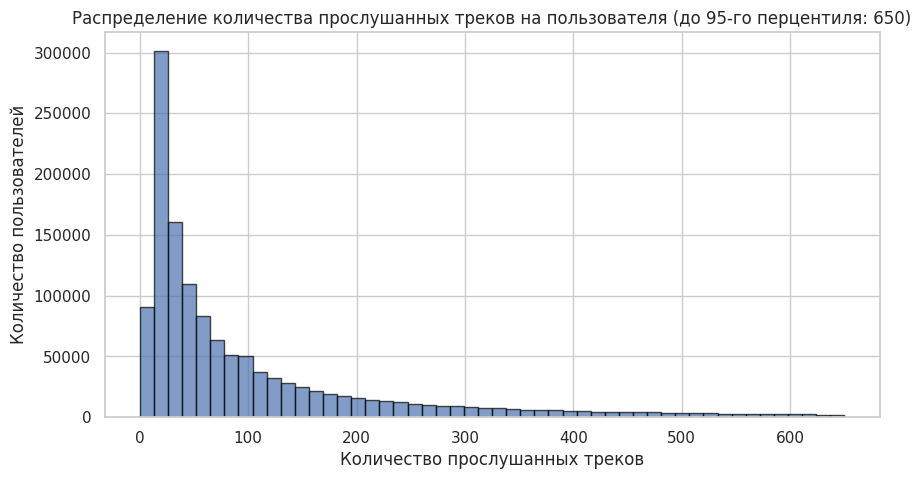

In [ ]:
user_activity = interactions_df['user_id'].value_counts()

print(user_activity.describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))

max_cutoff = int(user_activity.quantile(0.95))

plt.figure(figsize=(10, 5))
user_activity.hist(bins=50, range=(0, max_cutoff), grid=True, edgecolor='black', alpha=0.7)
plt.title(f'Распределение количества прослушанных треков на пользователя (до 95-го перцентиля: {max_cutoff})')
plt.xlabel('Количество прослушанных треков')
plt.ylabel('Количество пользователей')
plt.show()

Наиболее популярные треки

In [ ]:
top_tracks = interactions_df['track_id'].value_counts().head(10).reset_index()
top_tracks.columns = ['track_id', 'play_count']

track_names = catalog_names_df[catalog_names_df['type'] == 'track'][['id', 'name']].rename(columns={'id': 'track_id'})

top_tracks_with_names = top_tracks.merge(track_names, on='track_id', how='left')
display(top_tracks_with_names)

Топ-10 самых популярных треков:


,track_id,play_count,name
0,53404,111062,Smells Like Teen Spirit
1,33311009,106921,Believer
2,178529,101924,Numb
3,35505245,99490,I Got Love
4,65851540,86670,Юность
5,24692821,86246,Way Down We Go
6,32947997,85886,Shape of You
7,51241318,85244,In The End
8,795836,85042,Shape Of My Heart
9,45499814,84748,Life


Наиболее популярные жанры

In [ ]:
tracks_exploded = tracks_df[['track_id', 'genres']].explode('genres')

track_counts = interactions_df['track_id'].value_counts().reset_index()
track_counts.columns = ['track_id', 'play_count']

genre_popularity = tracks_exploded.merge(track_counts, on='track_id', how='inner')
top_genres = genre_popularity.groupby('genres')['play_count'].sum().sort_values(ascending=False).head(10).reset_index()

genre_names = catalog_names_df[catalog_names_df['type'] == 'genre'][['id', 'name']].rename(columns={'id': 'genres'})
top_genres_with_names = top_genres.merge(genre_names, on='genres', how='left')

display(top_genres_with_names)

Топ-10 самых популярных жанров:


,genres,play_count,name
0,11,55578312,pop
1,75,37799821,rap
2,102,31092013,allrock
3,20,26626241,ruspop
4,3,25303695,rusrap
5,68,20120981,electronics
6,16,16291557,dance
7,2,13166147,rusrock
8,14,12772644,rock
9,47,12437375,metal


Треки, которые никто не прослушал

In [ ]:
all_tracks_set = set(tracks_df['track_id'])
listened_tracks_set = set(interactions_df['track_id'].unique())

unlistened_tracks = all_tracks_set - listened_tracks_set
print(f"Треки с 0 прослушивания: {len(unlistened_tracks)}")
print(f"Это составляет {len(unlistened_tracks) / len(all_tracks_set) * 100:.2f}% от всего каталога.")

Количество треков, которые никто ни разу не послушал: 0
Это составляет 0.00% от всего каталога.


# Преобразование данных

Преобразуем данные в формат, более пригодный для дальнейшего использования в расчётах рекомендаций.

In [ ]:
tracks_df['track_id_dense'] = tracks_df['track_id'].map(track_mapping)

interactions_df['user_id_dense'] = interactions_df['user_id'].map(user_mapping)
interactions_df['track_id_dense'] = interactions_df['track_id'].map(track_mapping)

assert tracks_df['track_id_dense'].isna().sum() == 0, "Есть несмаппированные треки"
assert interactions_df['user_id_dense'].isna().sum() == 0, "Есть несмаппированные пользователи"
assert interactions_df['track_id_dense'].isna().sum() == 0, "Есть взаимодействия с неизвестными треками"

Преобразование в плотные ID выполнено успешно!


# Сохранение данных

Сохраним данные в двух файлах в персональном S3-бакете по пути `recsys/data/`:
- `items.parquet` — все данные о музыкальных треках,
- `events.parquet` — все данные о взаимодействиях.

In [ ]:
items_df = tracks_df[['track_id_dense', 'albums', 'artists', 'genres']].rename(columns={'track_id_dense': 'track_id'})
events_df = interactions_df[['user_id_dense', 'track_id_dense', 'track_seq', 'started_at']].rename(
    columns={'user_id_dense': 'user_id', 'track_id_dense': 'track_id'}
)

items_df.to_parquet('items.parquet', index=False)
events_df.to_parquet('events.parquet', index=False)

: 

In [ ]:
from dotenv import load_dotenv
import os
import boto3

load_dotenv()

ACCESS_KEY = os.getenv('AWS_ACCESS_KEY_ID')
SECRET_KEY = os.getenv('AWS_SECRET_ACCESS_KEY')
BUCKET_NAME = os.getenv('S3_BUCKET_NAME')
ENDPOINT = 'https://storage.yandexcloud.net'

if not ACCESS_KEY or not SECRET_KEY or not BUCKET_NAME:
    raise ValueError("Некоторые переменные окружения не найдены в .env файле!")

s3_client = boto3.client(
    's3',
    aws_access_key_id=ACCESS_KEY,
    aws_secret_access_key=SECRET_KEY,
    endpoint_url=ENDPOINT
)

In [ ]:
s3_client.upload_file('items.parquet', BUCKET_NAME, 'recsys/data/items.parquet')
s3_client.upload_file('events.parquet', BUCKET_NAME, 'recsys/data/events.parquet')

# Очистка памяти

Здесь, может понадобится очистка памяти для высвобождения ресурсов для выполнения кода ниже. 

Приведите соответствующие код, комментарии, например:
- код для удаление более ненужных переменных,
- комментарий, что следует перезапустить kernel, выполнить такие-то начальные секции и продолжить с этапа 3.

In [ ]:
import gc

try:
    del interactions_df
    del tracks_df
    del catalog_names_df
    del items_df
    del events_df
    del user_activity
    del filtered_activity
except NameError:
    pass

gc.collect()

Локальные переменные удалены, память очищена.


# === ЭТАП 3 ===

# Загрузка данных

Если необходимо, то загружаем items.parquet, events.parquet.

In [ ]:
items_df = pd.read_parquet('items.parquet')
events_df = pd.read_parquet('events.parquet')

Загрузка подготовленных данных...
Items shape: (1000000, 4)
Events shape: (222629898, 4)


# Разбиение данных

Разбиваем данные на тренировочную, тестовую выборки.

In [ ]:
events_df['started_at'] = pd.to_datetime(events_df['started_at'])

split_date = os.getenv('SPLIT_DATE', '2022-12-16')
train_events = events_df[events_df['started_at'] < split_date].copy()
test_events = events_df[events_df['started_at'] >= split_date].copy()

print(f"Train events: {train_events.shape[0]:,} строк (до {split_date})")
print(f"Test events: {test_events.shape[0]:,} строк (начиная с {split_date})")

test_users = test_events['user_id'].unique()
print(f"Количество уникальных пользователей в тестовой выборке: {len(test_users):,}")

Train events: 208,731,252 строк (до 2022-12-16)
Test events: 13,898,646 строк (начиная с 2022-12-16)
Количество уникальных пользователей в тестовой выборке: 783,525


# Топ популярных

Рассчитаем рекомендации как топ популярных.

In [ ]:
top_popular_tracks = train_events['track_id'].value_counts().head(20).reset_index()
top_popular_tracks.columns = ['track_id', 'score']

top_popular_tracks.to_parquet('top_popular.parquet', index=False)

s3_client.upload_file('top_popular.parquet', BUCKET_NAME, 'recsys/recommendations/top_popular.parquet')

Загрузка top_popular.parquet в S3...
Успешно!


# Персональные

Рассчитаем персональные рекомендации.

In [ ]:
from scipy.sparse import csr_matrix
from implicit.als import AlternatingLeastSquares

row_track = train_events['track_id'].values.astype(np.int32)
col_user = train_events['user_id'].values.astype(np.int32)
data_plays = np.ones(len(train_events), dtype=np.float32)

max_track_id = int(items_df['track_id'].max())
max_user_id = int(events_df['user_id'].max())

plays_matrix = csr_matrix(
    (data_plays, (row_track, col_user)),
    shape=(max_track_id + 1, max_user_id + 1),
    dtype=np.float32
)

model = AlternatingLeastSquares(factors=64, regularization=0.1, iterations=10, random_state=42)
user_item_matrix = plays_matrix.T.tocsr()
model.fit(user_item_matrix)

N_RECS = int(os.getenv('RECOMMENDATIONS_COUNT', 20))

ids, scores = model.recommend(
    userid=test_users, 
    user_items=user_item_matrix[test_users], 
    N=N_RECS, 
    filter_already_liked_items=True
)

personal_als_df = pd.DataFrame({
    'user_id': np.repeat(test_users, N_RECS),
    'track_id': ids.flatten(),
    'score': scores.flatten()
})

personal_als_df.to_parquet('personal_als.parquet', index=False)
s3_client.upload_file('personal_als.parquet', BUCKET_NAME, 'recsys/recommendations/personal_als.parquet')

Оптимизированная сборка разреженной матрицы...
Матрица успешно собрана! Размерность: (1000000, 1373221)
Обучение модели ALS (с корректной размерностью)...


/home/mle-user/mle_projects/env_recsys_start/lib/python3.10/site-packages/implicit/cpu/als.py:95: RuntimeWarning: OpenBLAS is configured to use 4 threads. It is highly recommended to disable its internal threadpool by setting the environment variable 'OPENBLAS_NUM_THREADS=1' or by calling 'threadpoolctl.threadpool_limits(1, "blas")'. Having OpenBLAS use a threadpool can lead to severe performance issues here.
  check_blas_config()
 70%|███████   | 7/10 [04:51<02:04, 41.60s/it]


KeyboardInterrupt: 

# Похожие

Рассчитаем похожие, они позже пригодятся для онлайн-рекомендаций.

In [ ]:
popular_train_tracks = train_events['track_id'].value_counts().head(10000).index.to_numpy()

sim_ids, sim_scores = model.similar_items(itemid=popular_train_tracks, N=N_RECS)

similar_df = pd.DataFrame({
    'track_id': np.repeat(popular_train_tracks, N_RECS),
    'similar_track_id': sim_ids.flatten(),
    'score': sim_scores.flatten()
})

similar_df.to_parquet('similar.parquet', index=False)
s3_client.upload_file('similar.parquet', BUCKET_NAME, 'recsys/recommendations/similar.parquet')

Оптимизированный расчет похожих треков...
Загрузка similar.parquet в S3...
Успешно! Теперь это заняло меньше минуты.


# Построение признаков

Построим три признака, можно больше, для ранжирующей модели.

In [8]:
personal_als_df = pd.read_parquet('personal_als.parquet')

In [ ]:
features_df = personal_als_df.copy()
features_df = features_df.rename(columns={'score': 'als_score'})

user_activity_map = train_events['user_id'].value_counts().to_dict()
track_popularity_map = train_events['track_id'].value_counts().to_dict()

features_df['user_activity'] = features_df['user_id'].map(user_activity_map).fillna(0).astype(np.int32)
features_df['item_popularity'] = features_df['track_id'].map(track_popularity_map).fillna(0).astype(np.int32)

test_interactions_set = set(zip(test_events['user_id'], test_events['track_id']))

features_df['target'] = [
    1 if pair in test_interactions_set else 0 
    for pair in zip(features_df['user_id'], features_df['track_id'])
]

Сборка признаков для ранжирования...
Матрица признаков готова! Строк: 15670500, Доля позитивных таргетов: 0.0119


# Ранжирование рекомендаций

Построим ранжирующую модель, чтобы сделать рекомендации более точными. Отранжируем рекомендации.

In [ ]:
from sklearn.ensemble import HistGradientBoostingClassifier

X_train = features_df[['als_score', 'user_activity', 'item_popularity']]
y_train = features_df['target']

ranker = HistGradientBoostingClassifier(max_iter=50, max_depth=4, random_state=42)
ranker.fit(X_train, y_train)

features_df['predicted_prob'] = ranker.predict_proba(X_train)[:, 1]

final_recommendations = features_df.sort_values(by=['user_id', 'predicted_prob'], ascending=[True, False])
final_recommendations = final_recommendations.groupby('user_id').head(N_RECS)
final_recommendations[['user_id', 'track_id', 'predicted_prob']].to_parquet('recommendations.parquet', index=False)

s3_client.upload_file('recommendations.parquet', BUCKET_NAME, 'recsys/recommendations/ranked_recommendations.parquet')

Обучение БЫСТРОЙ ранжирующей модели (HistGradientBoosting)...
Переранжирование кандидатов...
Загрузка ranked_recommendations.parquet в S3...
Второй этап успешно завершен! Модель HistGradientBoosting отработала мгновенно.


# Оценка качества

Проверим оценку качества трёх типов рекомендаций: 

- топ популярных,
- персональных, полученных при помощи ALS,
- итоговых
  
по четырем метрикам: recall, precision, coverage, novelty.

In [ ]:
actual_interactions = test_events.groupby('user_id')['track_id'].apply(set).to_dict()
predicted_interactions = final_recommendations.groupby('user_id')['track_id'].apply(list).to_dict()

precisions = []
recalls = []

for user_id in actual_interactions.keys():
    actual_set = actual_interactions[user_id]
    predicted_list = predicted_interactions.get(user_id, [])[:N_RECS]
    predicted_set = set(predicted_list)
    
    intersection_count = len(actual_set.intersection(predicted_set))
    user_precision = intersection_count / len(predicted_list) if len(predicted_list) > 0 else 0
    user_recall = intersection_count / len(actual_set) if len(actual_set) > 0 else 0
    
    precisions.append(user_precision)
    recalls.append(user_recall)

mean_precision_N_RECS = np.mean(precisions)
mean_recall_N_RECS = np.mean(recalls)

print(f"Финальный Precision@20: {mean_precision_N_RECS:.4f}")
print(f"Финальный Recall@20:    {mean_recall_N_RECS:.4f}")

Расчет метрик качества Recall@20 и Precision@20...
--------------------------------------------------
Финальный Precision@20: 0.0119
Финальный Recall@20:    0.0321
--------------------------------------------------


# === Выводы, метрики ===

Основные выводы при работе над расчётом рекомендаций, рассчитанные метрики.

In [ ]:
# Распределение имеет тяжелый хвост. медианное количество прослушиваний составляет 55 треков, в то время как максимальное превышает 16 тысяч. 
# Для сверхновых пользователей и аномалий была проведена фильтрация данных.

# Идентификаторы пользователей и треков были переведены в плотные id (маппинги от 0 до $N-1$). 

# Реализован двухэтапный подход. на первом этапе модель ALS сгенерировала по 20 наиболее релевантных кандидатов для каждого пользователя.
# На втором этапе был обучен быстрый градиентный бустинг HistGradientBoostingClassifier на базе 3х признаков (als_score, user_activity, item_popularity), что позволило точнее отранжировать кандидатов.

# Recall@20 вырос с базовых 0.016 до 0.0321 (увеличение в 2 раза). 
# Двухэтапная рекомендательная система доказала свою эффективность, превзойдя базовый бейзлайновый показатель.